In [ ]:
# Run this setup only in Google Colab
import os
import subprocess
import sys

try:
    from google.colab import drive
    drive.mount("/content/drive")
    os.chdir("/content/drive/MyDrive/Colab Notebooks/ml2_trabalhos_2026")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-r", "requirements.txt"])
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-e", ".", "--no-deps"])
except ModuleNotFoundError:
    print("Not running in Colab; skipping Drive mount and install steps.")

# Trabalho 1 — Classificação de imagens com o Oxford-IIIT Pet

Neste trabalho, você irá treinar e comparar diferentes modelos para classificação de raças no dataset **Oxford-IIIT Pet**.

**Objetivos.**
- construir um pipeline básico de classificação de imagens;
- comparar arquiteturas simples e profundas;
- investigar o efeito de escolhas de treinamento;
- analisar erros e limitações do modelo.

**Entregáveis.**
1. Este notebook preenchido e executado.
2. Os pesos do melhor modelo;
2. Respostas curtas e objetivas nas células de texto.
3. Tabelas e gráficos pedidos ao longo do trabalho.

**Regras gerais.**
- Use **PyTorch**.
- Registre as escolhas principais de hiperparâmetros.
- Quando o enunciado pedir comparação, use evidências dos seus resultados.
- Não apague as células do enunciado.
- Use o conjunto de **teste** apenas na etapa final.



## Parte 0 — Setup e reprodutibilidade

Como treinamos algoritmos que possuem escolhas randômicas, e em máquinas com configurações possivelmente distintas. É importante tentar controlar essas variáveis para garantirmos o máximo de reprodutibilidade dos nossos experimentos.

**Tarefa 0.1**  
Fixe as seeds aleatórias e configure o dispositivo (`cpu` ou `cuda`).

**Tarefa 0.2**  
Imprima as versões de `torch` e `torchvision`, e indique se o notebook está usando CPU ou GPU.

**Tarefa 0.3**  
Crie uma variável `student_run_tag` com uma string curta de sua escolha (por exemplo, suas iniciais e a data).  
Use essa tag ao salvar modelos, figuras e demais artefatos produzidos no notebook.



In [51]:
# TODO: importe as bibliotecas principais
import random
import numpy as np
from pathlib import Path

import torch
import torchvision
from torchvision.datasets import OxfordIIITPet
from torchvision import transforms
from torch.utils.data import DataLoader, random_split
from torch import nn
# Sugestão: complete com torch.nn, torch.optim, matplotlib etc.

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Semente: {seed}")
print(f"Dispositivo: {device}")
print("Versão do Torch:", torch.__version__)
print("Versão do Torchvision:", torchvision.__version__)

student_run_tag = "tom0204"
output_dir = Path("assignment1_outputs")
output_dir.mkdir(exist_ok=True)
(output_dir / student_run_tag).mkdir(exist_ok=True)
print("Diretório de saída:", output_dir / student_run_tag)

Semente: 42
Dispositivo: cuda
Versão do Torch: 2.11.0+cu126
Versão do Torchvision: 0.26.0+cu126
Diretório de saída: assignment1_outputs/tom0204


## 1. Carregar dados e fazer split

Use o dataset **Oxford-IIIT Pet** do `torchvision`.

**Tarefas**
1. Baixe/carregue o dataset.
2. Separe os dados em **treino**, **validação** e **teste**.
3. Explique brevemente qual split você usou.
4. Mostre o número de exemplos em cada parte.

**Observação.**
- Você pode usar o split oficial de treino/teste e separar parte do treino para validação.
- Para a maior parte do trabalho, use inicialmente transformações simples.


In [52]:
# TODO:
# - importar OxfordIIITPet
# - definir transformações iniciais
# - carregar conjuntos
# - criar split treino/validação
# - criar DataLoaders

# Estrutura sugerida:

#image_size = 224
#batch_size = 64

# Escreva seu código aqui

# note que o dataset já foi importado na célula acima
image_size = 224
batch_size = 64

"""
Definindo transformações
"""

my_transforms = transforms.Compose([
transforms.Resize((image_size,image_size)), # padronizando tamanho das imagens
transforms.ToTensor(), # números entre 0 e 1
transforms.Normalize(mean=[0.485,0.456,0.426], std=[0.229,0.224,0.225]) # normalizando
])

"""
Carregar conjuntos
"""

trainval_dataset = OxfordIIITPet(
    root = './data', 
    download = True, 
    transform = my_transforms, 
    split = "trainval"
)
test_dataset =  OxfordIIITPet(
    root = './data', 
    download = True, 
    transform = my_transforms, 
    split = "test"
)

"""
Split treino/validação
"""

len_train = int(len(trainval_dataset)*0.8)
len_val = len(trainval_dataset) - len_train

generator = torch.Generator().manual_seed(seed)
train_dataset, val_dataset = random_split(trainval_dataset, [len_train, len_val], generator = generator)

"""
Criando dataloaders
"""

train_dataloader = DataLoader(train_dataset, batch_size = batch_size, shuffle=True, generator = generator)
val_dataloader = DataLoader(val_dataset, batch_size = batch_size, shuffle = False, generator = generator)
test_dataloader = DataLoader(test_dataset, batch_size = batch_size, shuffle= False, generator = generator)

### Resposta 1.3

Explique brevemente como você construiu o split de treino, validação e teste.

O dataset já é separado em dados de teste e de treino/validação (trainval). Separei de forma aleatória 80% dos dados de trainval como treino e o restante como validação.

## 2. Visualizar dados e inspecionar balanceamento

Antes de treinar, inspecione o dataset.

**Tarefas**
1. Mostre algumas imagens com seus rótulos.
2. Conte quantos exemplos há por classe no conjunto de treino.
3. Faça um gráfico simples da distribuição por classe.
4. Comente se o conjunto parece balanceado ou não.
5. Aponte ao menos uma dificuldade visual do problema.

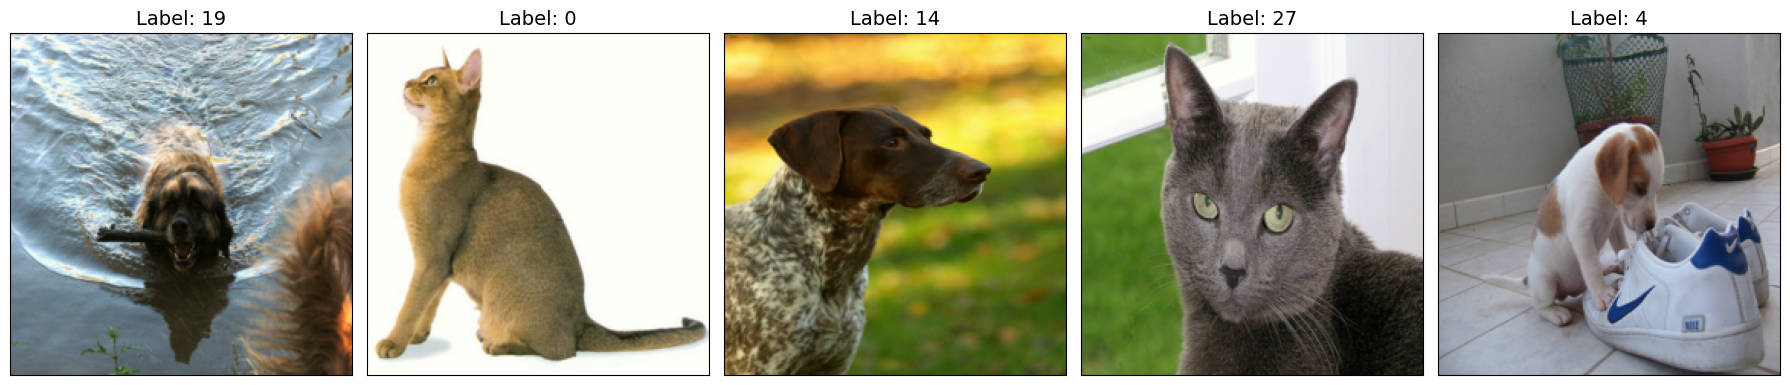

class_names: ['Abyssinian', 'American Bulldog', 'American Pit Bull Terrier', 'Basset Hound', 'Beagle', 'Bengal', 'Birman', 'Bombay', 'Boxer', 'British Shorthair', 'Chihuahua', 'Egyptian Mau', 'English Cocker Spaniel', 'English Setter', 'German Shorthaired', 'Great Pyrenees', 'Havanese', 'Japanese Chin', 'Keeshond', 'Leonberger', 'Maine Coon', 'Miniature Pinscher', 'Newfoundland', 'Persian', 'Pomeranian', 'Pug', 'Ragdoll', 'Russian Blue', 'Saint Bernard', 'Samoyed', 'Scottish Terrier', 'Shiba Inu', 'Siamese', 'Sphynx', 'Staffordshire Bull Terrier', 'Wheaten Terrier', 'Yorkshire Terrier']
#class_names: 37
counts(dict): Counter({3: 87, 6: 86, 4: 85, 13: 85, 14: 84, 15: 84, 21: 84, 2: 83, 36: 83, 24: 83, 0: 82, 16: 82, 31: 81, 25: 81, 23: 81, 32: 81, 9: 80, 35: 80, 7: 80, 30: 79, 5: 79, 27: 78, 33: 78, 8: 78, 28: 78, 1: 78, 26: 77, 29: 77, 12: 77, 10: 77, 20: 76, 34: 76, 19: 75, 18: 75, 22: 73, 17: 71, 11: 70})
maior frequência: 87
menor frequência: 70


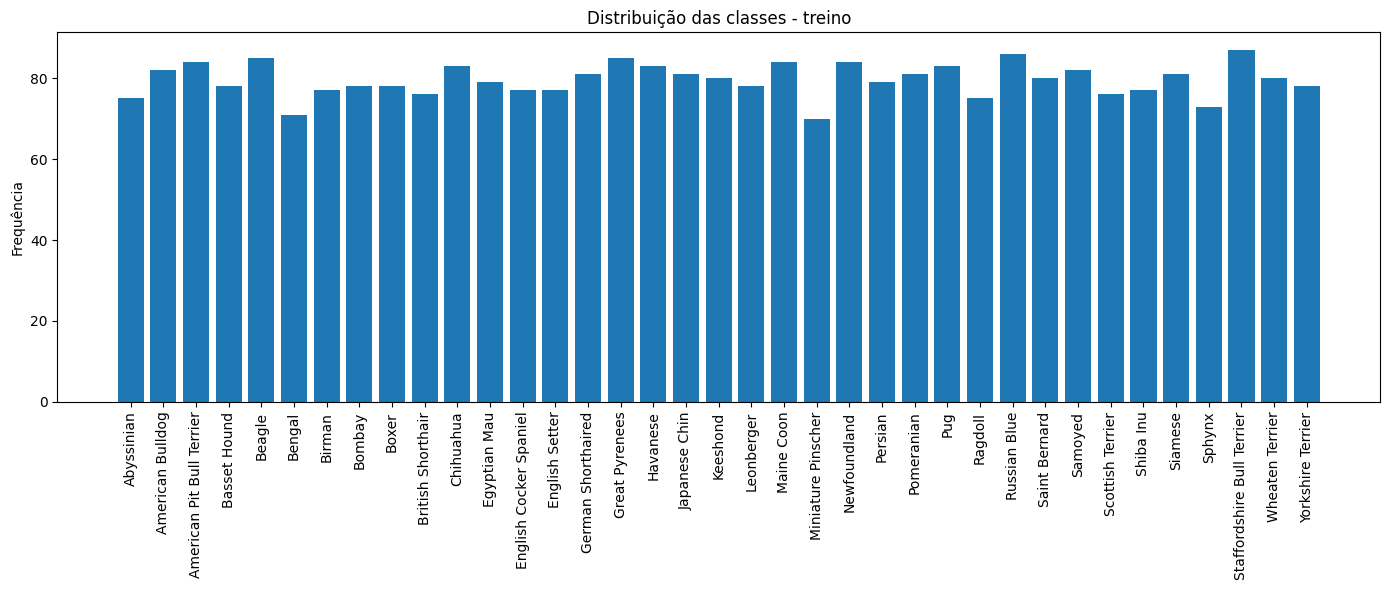

In [53]:
# TODO:
# - mostrar algumas imagens do treino
# - obter nomes/classes
# - contar frequência por classe
# - fazer um gráfico simples

import matplotlib.pyplot as plt
from collections import Counter
import torchvision.transforms.functional as F

"""
Imagens de treino
"""
def show(imgs, labels):
#função tirada e modificada da documentação do pytorch https://docs.pytorch.org/vision/main/auto_examples/others/plot_visualization_utils.html
    fig, axs = plt.subplots(ncols=len(imgs), figsize=(18, 5), squeeze=False)
    # para visualizar vamos desnomalizar as imagens
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    for i, (img, label) in enumerate(zip(imgs, labels)):
        img = img.detach()
        img_desnorm = img*std + mean
        img_desnorm = torch.clamp(img_desnorm, 0, 1) #alguns pontos pretos estavam ficando azuis. Essa função limita of valores para o intervalo [0,1]
        img_desnorm = F.to_pil_image(img_desnorm)

        axs[0, i].imshow(np.asarray(img_desnorm))
        axs[0, i].set(xticklabels=[], yticklabels=[], xticks=[], yticks=[])
        axs[0, i].set_title(f"Label: {label}", fontsize=14)
        
    plt.tight_layout()
    plt.show()

img_list = [ train_dataset[i][0] for i in range(5)]
label_list = [ train_dataset[i][1] for i in range(5)]

show(img_list, label_list)

"""
nomes/classes
"""
class_names = trainval_dataset.classes # atributo nativo dos datasets do torchvision.datasets

print(f'class_names: {class_names}')
print(f'#class_names: {len(class_names)}')

"""
frequência por classe
"""
counts = Counter([trainval_dataset._labels[i] for i in train_dataset.indices])

print(f"counts(dict): {counts}")
print(f"maior frequência: {max(counts.values())}")
print(f"menor frequência: {min(counts.values())}")

"""
plot
"""


plt.figure(figsize=(14,6))
plt.bar(class_names, counts.values())
plt.xticks(rotation=90)
plt.ylabel("Frequência")
plt.title("Distribuição das classes - treino")
plt.tight_layout()
plt.show()



### Resposta 2.4–2.5

Todas as classes apresentam entre 70 e 87 amostras, logo o dataset de treino parece balanceado.

Dificuldade: as imagens não têm o mesmo tamanho, logo foi preciso redimensiná-las, para que ficassem todas com dim 224x224. Além disso, diferenciar raças como American Bulldog e Boxer pode ser difícil até para humanos.

## 3. Construa uma FNN simples

Agora construa um primeiro modelo totalmente conectado (**FNN**).

**Tarefas**
1. Defina uma arquitetura simples em PyTorch.
2. Sua FNN deve receber a imagem achatada.
3. Escolha dimensões ocultas razoáveis.
4. Informe o número de parâmetros do modelo.

**Observação.**
Este modelo serve como baseline simples. Não é esperado que funcione bem.


In [72]:
# TODO:
# - definir uma classe FNN(nn.Module)
# - achatar a entrada
# - retornar logits para o número de classes
# - criar uma instância do modelo

# Dica:
# class SimpleFNN(nn.Module):
#     ...

# Escreva seu código aqui

class SimpleFNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten() # transforma a entrada (imagem) em um tensor 1-dimensional (achata a entrada)
        self.network = nn.Sequential(
            nn.Linear(3*224*224, 512),
            nn.ReLU(),
            nn.Linear(512,256),
            nn.ReLU(),
            nn.Linear(256,128),
            nn.ReLU(),
            nn.Linear(128,37),
        )
    def forward(self,x):
        x = self.flatten(x)
        logits = self.network(x)
        return logits
    
model_fnn = SimpleFNN() # instância para o modelo
print(model_fnn)



SimpleFNN(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (network): Sequential(
    (0): Linear(in_features=150528, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): ReLU()
    (6): Linear(in_features=128, out_features=37, bias=True)
  )
)


`Números de parâmetros do modelo`

Primeira camada: $3 \cdot 224 \cdot 224\cdot 512 + 512$

Segunda camada: $512 \cdot 256 + 256$

Terceira camada: $256 \cdot 128 + 128$

Quarta camada: $128 \cdot 37 + 37$

Logo, temos no total aproximadamente 77 milhões de parâmetros.

## 4. Crie funções de treino e avaliação

Implemente funções reutilizáveis para os próximos experimentos.

**Tarefas**
1. Crie uma função `train_one_epoch`.
2. Crie uma função `evaluate`.
3. Crie uma função `fit` que registre métricas por época.
4. Sua avaliação deve retornar pelo menos:
   - loss média
   - acurácia

**Importante.**
Essas funções serão reutilizadas em várias partes do trabalho.


In [ ]:
# TODO:
# - implementar train_one_epoch
# - implementar evaluate
# - implementar fit
# - opcional: salvar histórico em dicionário

# Assinaturas sugeridas:
# def train_one_epoch(model, loader, optimizer, criterion, device):
#     ...
#            nn.Linear(
#
# @torch.no_grad()
# def evaluate(model, loader, criterion, device):
#     ...
#
# def fit(model, train_loader, val_loader, optimizer, criterion, device, epochs, scheduler=None):
#     ...

# Escreva seu código aqui

def _train_one_epoch(model, loader, optmizer, criterion, device):
    model.train()

    train_loss, correct = 0.0, 0.0

    for batch, (X,y) in enumerate(loader):
        X,y = X.to(device), y.to(device)
        pred = model(X)
        loss = criterion(pred,y)

        optmizer.zero_grad()
        loss.backward()
        optmizer.step()

        train_loss += criterion(pred,y).item()
        correct += (pred.argmax(1)==y).type(torch.float).sum().item()

    if (batch%100 == 0): print(f'loss: {loss:>7}')

    return train_loss/ len(loader), correct/ len(loader.dataset) 

@torch.no_grad
def _evaluate(model, loader, criterion, device):
    model.eval()
    size = len(loader.dataset)
    num_batches = len(loader)
    test_loss, correct = 0,0

    for X,y in loader:
        X,y = X.to(device), y.to(device)
        pred = model(X)
        test_loss += criterion(pred,y).item()
        correct += (pred.argmax(1)==y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct = correct/size

    return test_loss, correct

def fit(model, train_loader, val_loader, optmizer, criterion, device, epochs, scheduler=None):
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': []
    }
    for epoch in range(epochs):
        print(f"Epoch {epoch+1}\n-------------------------------")
        t_loss, t_acc = _train_one_epoch(model, train_loader, optmizer, criterion, device)
        v_loss, v_acc = _evaluate(model, val_loader, criterion, device)

        history['train_loss'].append(t_loss)
        history['train_acc'].append(t_acc)
        history['val_loss'].append(v_loss)
        history['val_acc'].append(v_acc)

        print(f't_loss: {t_loss}| t_acc: {t_acc}| v_loss: {v_loss}| v_acc: {v_acc}')

    return history

def plot_history(history, title="Histórico de Treinamento"):

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    epochs = range(1, len(history['train_loss']) + 1)
    
    # Gráfico loss 
    ax1.plot(epochs, history['train_loss'], label='Treino', color='blue', linewidth=2)
    ax1.plot(epochs, history['val_loss'], label='Validação', color='red', linewidth=2, linestyle='--')
    ax1.set_title("Evolução da Loss (Custo)")
    ax1.set_xlabel("Épocas")
    ax1.set_ylabel("Loss")
    ax1.legend()
    ax1.grid(True, linestyle=':', alpha=0.7)
    
    # Gráfico  acc
    ax2.plot(epochs, history['train_acc'], label='Treino', color='blue', linewidth=2)
    ax2.plot(epochs, history['val_acc'], label='Validação', color='red', linewidth=2, linestyle='--')
    ax2.set_title("Evolução da Acurácia")
    ax2.set_xlabel("Épocas")
    ax2.set_ylabel("Acurácia")
    ax2.legend()
    ax2.grid(True, linestyle=':', alpha=0.7)
    
    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

## 5. Treine e avalie a FNN

Use as funções anteriores para treinar sua FNN.

**Tarefas**
1. Escolha uma loss apropriada.
2. Escolha um otimizador.
3. Treine por algumas épocas.
4. Mostre curvas de treino/validação.
5. Reporte as métricas finais em validação.
6. Faça um comentário curto sobre o desempenho da FNN.

**Sugestão.**
Registre as escolhas de hiperparâmetros em uma célula ou tabela.


Epoch 1
-------------------------------
t_loss: 4.488567238268645| t_acc: 0.03940217391304348| v_loss: 3.6002826491991677| v_acc: 0.04483695652173913
Epoch 2
-------------------------------
t_loss: 3.589395155077395| t_acc: 0.042459239130434784| v_loss: 3.597213009993235| v_acc: 0.029891304347826088
Epoch 3
-------------------------------
t_loss: 3.5343558943789937| t_acc: 0.05332880434782609| v_loss: 3.5760104060173035| v_acc: 0.03125
Epoch 4
-------------------------------
t_loss: 3.475623737210813| t_acc: 0.06182065217391304| v_loss: 3.548290808995565| v_acc: 0.04755434782608696
Epoch 5
-------------------------------
t_loss: 3.3979001978169316| t_acc: 0.06963315217391304| v_loss: 3.61704158782959| v_acc: 0.04619565217391304
Epoch 6
-------------------------------
t_loss: 3.3631602214730303| t_acc: 0.07608695652173914| v_loss: 3.6266873478889465| v_acc: 0.050271739130434784
Epoch 7
-------------------------------
t_loss: 3.281458932420482| t_acc: 0.09442934782608696| v_loss: 3.65318

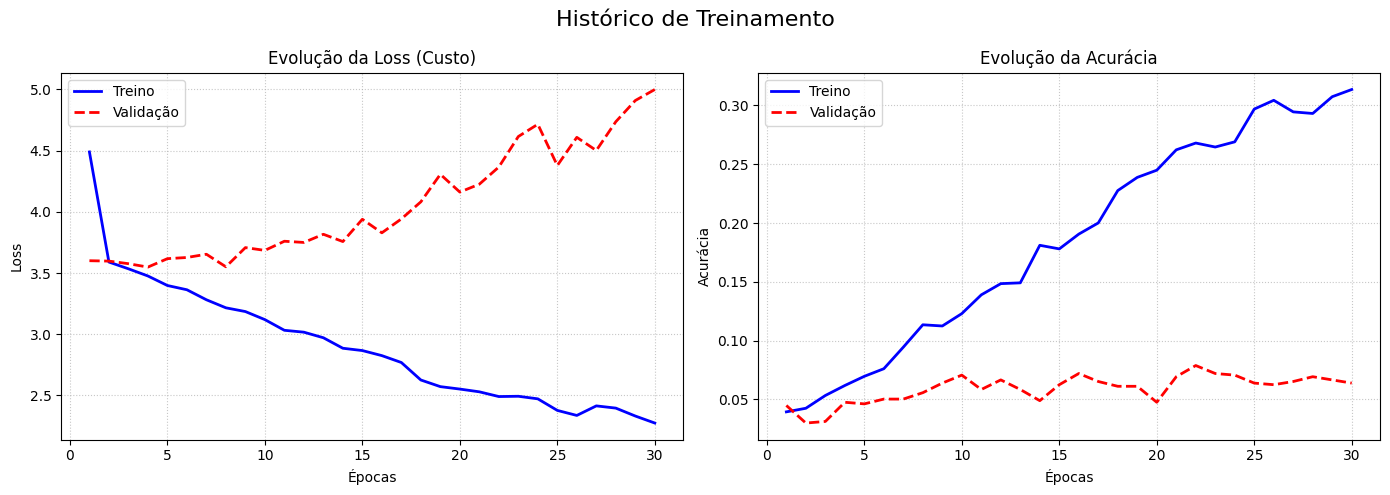

In [73]:
# TODO:
# - definir criterion e optimizer
# - treinar a FNN
# - guardar histórico
# - plotar curvas
# - reportar métricas finais

# Escreva seu código aqui

# device definido na primeira célula
learning_rate = 1e-3
epochs = 30
model_fnn = SimpleFNN()
model_fnn = model_fnn.to(device)

criterion = nn.CrossEntropyLoss()
optmizer = torch.optim.Adam(model_fnn.parameters(), learning_rate)

fnn_history = fit(model_fnn, train_dataloader, val_dataloader, optmizer, criterion, device, epochs)

plot_history(fnn_history)


### Resposta 5.6

Comente brevemente o desempenho da FNN. Ela parece adequada para esse problema? Por quê?

Ela não parece adequada, principalmente porque para ser computacionalmente vivável, diminuímos muito o tamanho das camadas em relação à primeira. Perceba que os 77 milhões de parâmetros que calculamos vêm quase todos da primeira camada. Assim, a rede não tem capacidade para aprender os padrões.


## 6. Construa uma CNN simples e compare com a FNN

Agora implemente uma CNN simples.

**Tarefas**
1. Defina uma CNN com algumas camadas convolucionais.
2. Treine e avalie a CNN usando o mesmo protocolo da FNN.
3. Compare FNN e CNN em termos de:
   - acurácia;
   - comportamento das curvas;
   - número de parâmetros.

**Observação.**
A comparação deve ser baseada nos seus resultados.


Epoch 1
-------------------------------
t_loss: 3.679324429968129| t_acc: 0.028532608695652172| v_loss: 3.5743332902590432| v_acc: 0.06521739130434782
Epoch 2
-------------------------------
t_loss: 3.48595668958581| t_acc: 0.06997282608695653| v_loss: 3.4141965905825296| v_acc: 0.08016304347826086
Epoch 3
-------------------------------
t_loss: 3.251636049021845| t_acc: 0.11956521739130435| v_loss: 3.3412097692489624| v_acc: 0.09646739130434782
Epoch 4
-------------------------------
t_loss: 2.956753601198611| t_acc: 0.1871603260869565| v_loss: 3.4017540216445923| v_acc: 0.09782608695652174
Epoch 5
-------------------------------
t_loss: 2.506059838377911| t_acc: 0.30570652173913043| v_loss: 3.5572559436162314| v_acc: 0.12228260869565218
Epoch 6
-------------------------------
t_loss: 1.8013725410337034| t_acc: 0.49184782608695654| v_loss: 4.062389433383942| v_acc: 0.10190217391304347
Epoch 7
-------------------------------
t_loss: 0.9468685181244559| t_acc: 0.735733695652174| v_loss:

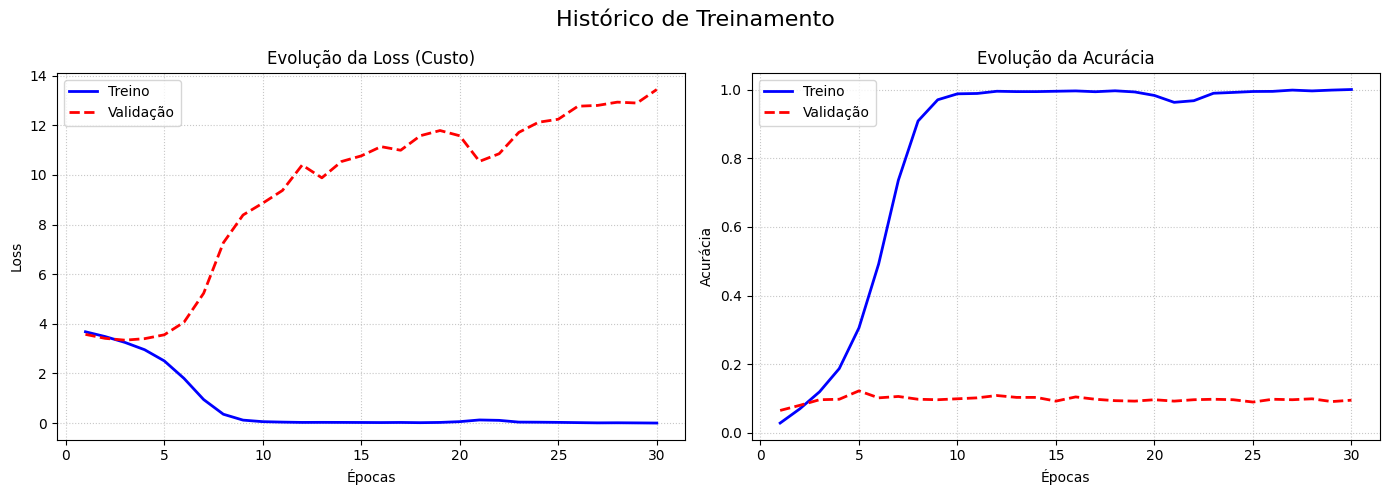

In [74]:
# TODO:
# - definir uma CNN simples
# - treinar
# - avaliar
# - comparar com a FNN

# Dica:
# class SimpleCNN(nn.Module):
#     ...

# Escreva seu código aqui

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(3,16,kernel_size= 3)
        self.cvrelu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2)

        self.conv2 = nn.Conv2d(16,64,kernel_size= 3)
        self.cvrelu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2)

        self.conv3 = nn.Conv2d(64,128,kernel_size= 3)
        self.cvrelu3 = nn.ReLU()
        self.pool3 = nn.MaxPool2d(kernel_size=2)

        self.flatten = nn.Flatten()
        
        self.fc1 = nn.Linear(128*26*26 , 128)
        self.fcrelu1 = nn.ReLU()

        self.fc2 = nn.Linear(128, 37) 
        
    def forward(self, x):
        x = self.pool1(self.cvrelu1(self.conv1(x)))
        x = self.pool2(self.cvrelu2(self.conv2(x)))
        x = self.pool3(self.cvrelu3(self.conv3(x)))
        
        x = self.flatten(x)
        
        x = self.fcrelu1(self.fc1(x))
        logits = self.fc2(x)
        
        return logits

model_simplecnn = SimpleCNN()

model_simplecnn = model_simplecnn.to(device)

criterion = nn.CrossEntropyLoss()
optmizer = torch.optim.Adam(model_simplecnn.parameters(), learning_rate)

simple_history = fit(model_simplecnn, train_dataloader, val_dataloader, optmizer, criterion, device, epochs)

plot_history(simple_history)

### Resposta 6.3

Compare FNN e CNN de forma objetiva. O que mudou? O resultado era esperado?

Podemos calcular o número de parâmetros da CNN:

conv1: $3^3 \cdot 16 + 16 = 448$
conv2: $3^2 \cdot 16 \cdot 64 + 64 = 9280$
conv3: $3^2 \cdot 64 \cdot 128 +128 = 73856$

fc1: $128 \cdot 26 \cdot 26 \cdot 128 + 128 = 11075712$
fc2: $128 \cdot 37 + 37 = 4773$

Portanto a SimpleCNN apresenta cerca de 11 milhões de parâmetros. Comparando as arquiteturas, a CNN a parece ser mais adequada para aprender padrões de imagens, o que se expressa na diminuição rápida na loss do treino (apesar de ter um sétimo do número de parâmetros). Apesar de percentualmente a CNN ter um resultado 50% melhor em acurácia do conjunto de validação, não é satisfatória em valores absolutos. 

## 7. Faça pelo menos 3 modificações no treinamento

A partir da sua CNN simples, escolha **pelo menos 3** modificações da lista abaixo:

- Data Augmentation;
- outro otimizador;
- learning rate scheduler;
- batch normalization;
- dropout;
- CNN mais profunda;
- weight decay regularizer.

**Tarefas**
1. Escolha no mínimo 3 modificações.
2. Execute experimentos controlados.
3. Organize os resultados em uma tabela.
4. Indique claramente qual configuração foi a melhor.

**Importante.**
Tente mudar uma coisa por vez sempre que possível.


In [58]:
# TODO:
# - definir ao menos 3 experimentos
# - treinar cada configuração
# - registrar resultados em uma tabela final

import copy

"""
Rede profunda
"""

class DeepCNN(nn.Module):
    def __init__(self):
        super().__init__()
    
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.conv12 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.relu12 = nn.ReLU()
        self.pool12 = nn.MaxPool2d(kernel_size=2)

        self.conv2 = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.conv22 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.relu22 = nn.ReLU()
        self.pool22 = nn.MaxPool2d(kernel_size=2)

        self.conv3 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.relu3 = nn.ReLU()
        self.conv32 = nn.Conv2d(64, 96, kernel_size=3, padding=1)
        self.relu32 = nn.ReLU()
        self.pool32 = nn.MaxPool2d(kernel_size=2)

    
        self.conv4 = nn.Conv2d(96, 96, kernel_size=3, padding=1)
        self.relu4 = nn.ReLU()
        self.conv42 = nn.Conv2d(96, 128, kernel_size=3, padding=1)
        self.relu42 = nn.ReLU()
        self.pool42 = nn.MaxPool2d(kernel_size=2)

        self.conv5 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.relu5 = nn.ReLU()
        self.conv52 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.relu52 = nn.ReLU()
        self.pool52 = nn.MaxPool2d(kernel_size=2)

        self.flatten = nn.Flatten()

        flatten_size = self._calc_flatten_size((3,224,224))

        
        self.fc1 = nn.Linear(flatten_size , 128)
        self.fcrelu1 = nn.ReLU()

        self.fc2 = nn.Linear(128, 37) 

    def _calc_flatten_size(self,shape):
        x = torch.zeros(1,*shape)

        x = self.relu1(self.conv1(x))
        x = self.pool12(self.relu12(self.conv12(x)))

        x = self.relu2(self.conv2(x))
        x = self.pool22(self.relu22(self.conv22(x)))

        x = self.relu3(self.conv3(x))
        x = self.pool32(self.relu32(self.conv32(x)))

        x = self.relu4(self.conv4(x))
        x = self.pool42(self.relu42(self.conv42(x)))

        x = self.relu5(self.conv5(x))
        x = self.pool52(self.relu52(self.conv52(x)))

        return x.numel()
        
    def forward(self, x):
        x = self.relu1(self.conv1(x))
        x = self.pool12(self.relu12(self.conv12(x)))

        x = self.relu2(self.conv2(x))
        x = self.pool22(self.relu22(self.conv22(x)))

        x = self.relu3(self.conv3(x))
        x = self.pool32(self.relu32(self.conv32(x)))

        x = self.relu4(self.conv4(x))
        x = self.pool42(self.relu42(self.conv42(x)))

        x = self.relu5(self.conv5(x))
        x = self.pool52(self.relu52(self.conv52(x)))
        
        x = self.flatten(x)
        
        x = self.fcrelu1(self.fc1(x))
        logits = self.fc2(x)
        
        return logits

model_deepcnn = DeepCNN()

"""
BatchNorms
"""

class BatchCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.bnorm0 = nn.BatchNorm2d(3)
        
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3)
        self.bnorm1 = nn.BatchNorm2d(16)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2)

        self.conv2 = nn.Conv2d(16, 64, kernel_size=3)
        self.bnorm2 = nn.BatchNorm2d(64)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3)
        self.bnorm3 = nn.BatchNorm2d(128)
        self.relu3 = nn.ReLU()
        self.pool3 = nn.MaxPool2d(kernel_size=2)

        self.flatten = nn.Flatten()

        flatten_size = self._calc_flatten_size((3,224,224))
        
        self.fc1 = nn.Linear(flatten_size , 128)
        self.fcrelu1 = nn.ReLU()

        self.fc2 = nn.Linear(128, 37) 
        
    def _calc_flatten_size(self, shape):
        x = torch.zeros(1, *shape)

        x = self.pool1(self.relu1(self.bnorm1(self.conv1(x))))

        x = self.pool2(self.relu2(self.bnorm2(self.conv2(x))))

        x = self.pool3(self.relu3(self.bnorm3(self.conv3(x))))

        return x.numel()
    
    def forward(self, x):
        x = self.bnorm0(x)
        x = self.pool1(self.relu1(self.bnorm1(self.conv1(x))))

        x = self.pool2(self.relu2(self.bnorm2(self.conv2(x))))

        x = self.pool3(self.relu3(self.bnorm3(self.conv3(x))))
        
        x = self.flatten(x)
        
        x = self.fcrelu1(self.fc1(x))
        logits = self.fc2(x)
        
        return logits

model_batchcnn = BatchCNN()

"""
Data augmentation
"""

train_transforms = torchvision.transforms.Compose([
    torchvision.transforms.Resize(256),
    torchvision.transforms.RandomCrop(224),

    torchvision.transforms.RandomHorizontalFlip(p=0.5),

    torchvision.transforms.RandomRotation(degrees = 15),

    torchvision.transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation= 0.2, hue= 0.1),

    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

"""
Nova rede com as três modificações, weight decay e dropout
"""
class CompleteCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.bnorm0 = nn.BatchNorm2d(3)
        
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.bnorm1 = nn.BatchNorm2d(16)
        self.relu1 = nn.ReLU()
        self.conv12 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.bnorm12 = nn.BatchNorm2d(32) 
        self.relu12 = nn.ReLU()
        self.pool12 = nn.MaxPool2d(kernel_size=2)

        self.conv2 = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.bnorm2 = nn.BatchNorm2d(32)
        self.relu2 = nn.ReLU()
        self.conv22 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bnorm22 = nn.BatchNorm2d(64)
        self.relu22 = nn.ReLU()
        self.pool22 = nn.MaxPool2d(kernel_size=2)

        self.conv3 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bnorm3 = nn.BatchNorm2d(64)
        self.relu3 = nn.ReLU()
        self.conv32 = nn.Conv2d(64, 96, kernel_size=3, padding=1)
        self.bnorm32 = nn.BatchNorm2d(96)
        self.relu32 = nn.ReLU()
        self.pool32 = nn.MaxPool2d(kernel_size=2)

    
        self.conv4 = nn.Conv2d(96, 96, kernel_size=3, padding=1)
        self.bnorm4 = nn.BatchNorm2d(96)
        self.relu4 = nn.ReLU()
        self.conv42 = nn.Conv2d(96, 128, kernel_size=3, padding=1)
        self.bnorm42 = nn.BatchNorm2d(128)
        self.relu42 = nn.ReLU()
        self.pool42 = nn.MaxPool2d(kernel_size=2)

        self.conv5 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.bnorm5 = nn.BatchNorm2d(128)
        self.relu5 = nn.ReLU()
        self.conv52 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.bnorm52 = nn.BatchNorm2d(128)
        self.relu52 = nn.ReLU()
        self.pool52 = nn.MaxPool2d(kernel_size=2)

        self.flatten = nn.Flatten()

        flatten_size = self._calc_flatten_size((3,224,224))

        self.dropout = nn.Dropout(p = 0.5)
        
        self.fc1 = nn.Linear(flatten_size , 512)
        self.fcrelu1 = nn.ReLU()

        self.fc2 = nn.Linear(512, 37) 
        
    def _calc_flatten_size(self,shape):
        x = torch.zeros(1,*shape)

        x = self.bnorm0(x)
        x = self.relu1(self.bnorm1(self.conv1(x)))
        x = self.pool12(self.relu12(self.bnorm12(self.conv12(x))))

        x = self.relu2(self.bnorm2(self.conv2(x)))
        x = self.pool22(self.relu22(self.bnorm22(self.conv22(x))))

        x = self.relu3(self.bnorm3(self.conv3(x)))
        x = self.pool32(self.relu32(self.bnorm32(self.conv32(x))))

        x = self.relu4(self.bnorm4(self.conv4(x)))
        x = self.pool42(self.relu42(self.bnorm42(self.conv42(x))))

        x = self.relu5(self.bnorm5(self.conv5(x)))
        x = self.pool52(self.relu52(self.bnorm52(self.conv52(x))))

        return x.numel()

    def forward(self, x):
        x = self.bnorm0(x)
        x = self.relu1(self.bnorm1(self.conv1(x)))
        x = self.pool12(self.relu12(self.bnorm12(self.conv12(x))))

        x = self.relu2(self.bnorm2(self.conv2(x)))
        x = self.pool22(self.relu22(self.bnorm22(self.conv22(x))))

        x = self.relu3(self.bnorm3(self.conv3(x)))
        x = self.pool32(self.relu32(self.bnorm32(self.conv32(x))))

        x = self.relu4(self.bnorm4(self.conv4(x)))
        x = self.pool42(self.relu42(self.bnorm42(self.conv42(x))))

        x = self.relu5(self.bnorm5(self.conv5(x)))
        x = self.pool52(self.relu52(self.bnorm52(self.conv52(x))))
        
        x = self.flatten(x)
        
        x = self.fcrelu1(self.fc1(x))

        x = self.dropout(x)

        logits = self.fc2(x)
        
        return logits
    
model_completecnn = CompleteCNN()

"""
Testes
"""

'\nTestes\n'

##### TREINANDO DEEPCNN #####
Epoch 1
-------------------------------
t_loss: 3.6123276015986567| t_acc: 0.02751358695652174| v_loss: 3.6130991180737815| v_acc: 0.017663043478260868
Epoch 2
-------------------------------
t_loss: 3.611398002375727| t_acc: 0.025475543478260868| v_loss: 3.613484025001526| v_acc: 0.017663043478260868
Epoch 3
-------------------------------
t_loss: 3.6112332706866055| t_acc: 0.029551630434782608| v_loss: 3.613988995552063| v_acc: 0.017663043478260868
Epoch 4
-------------------------------
t_loss: 3.6109619036964746| t_acc: 0.029551630434782608| v_loss: 3.6143966714541116| v_acc: 0.017663043478260868
Epoch 5
-------------------------------
t_loss: 3.6108541592307715| t_acc: 0.029551630434782608| v_loss: 3.6150337855021157| v_acc: 0.017663043478260868
Epoch 6
-------------------------------
t_loss: 3.6107257293618242| t_acc: 0.029551630434782608| v_loss: 3.6154340902964273| v_acc: 0.017663043478260868
Epoch 7
-------------------------------
t_loss: 3.610623

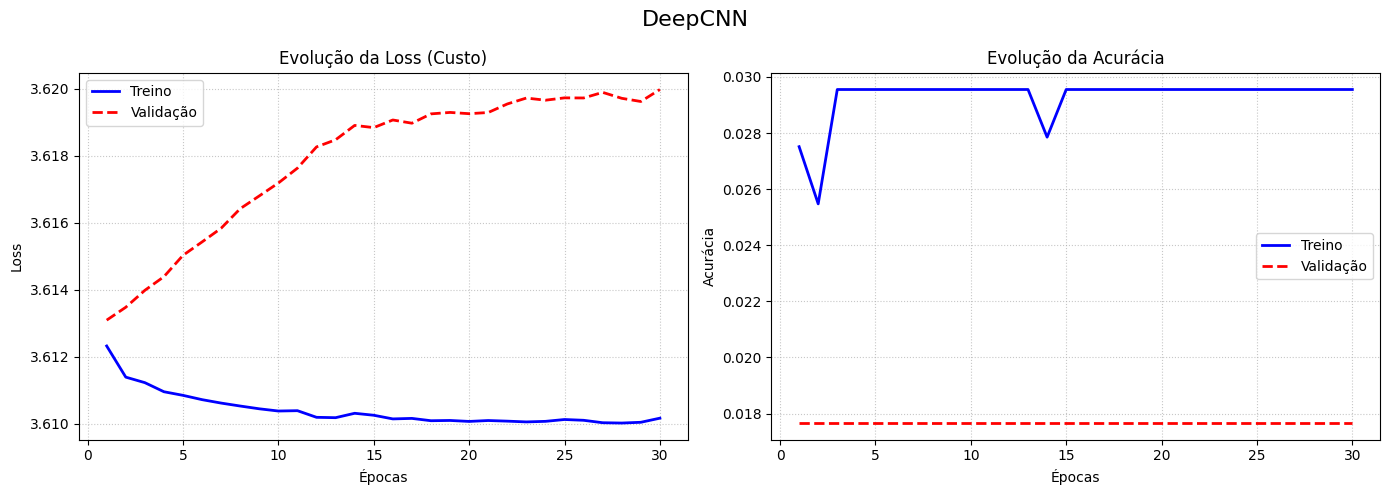

In [59]:
learning_rate = 1e-3

print('##### TREINANDO DEEPCNN #####')
epochs = 30
model_deepcnn = model_deepcnn.to(device)
optmizer = torch.optim.Adam(model_deepcnn.parameters(), learning_rate)
hist_deepcnn = fit(model_deepcnn, train_dataloader, val_dataloader, optmizer, criterion, device, epochs)
plot_history(hist_deepcnn, title="DeepCNN")

##### TREINANDO BATCHCNN #####
Epoch 1
-------------------------------
t_loss: 7.965449721916862| t_acc: 0.025135869565217392| v_loss: 3.614893833796183| v_acc: 0.024456521739130436
Epoch 2
-------------------------------
t_loss: 3.605617341787919| t_acc: 0.028532608695652172| v_loss: 3.605591654777527| v_acc: 0.024456521739130436
Epoch 3
-------------------------------
t_loss: 3.6078302756599756| t_acc: 0.027853260869565216| v_loss: 3.616842826207479| v_acc: 0.02717391304347826
Epoch 4
-------------------------------
t_loss: 3.6015413740406865| t_acc: 0.029891304347826088| v_loss: 3.6027026772499084| v_acc: 0.024456521739130436
Epoch 5
-------------------------------
t_loss: 3.6060104784758193| t_acc: 0.028872282608695652| v_loss: 3.6246383786201477| v_acc: 0.028532608695652172
Epoch 6
-------------------------------
t_loss: 3.6079343453697534| t_acc: 0.029211956521739132| v_loss: 3.6068930427233377| v_acc: 0.025815217391304348
Epoch 7
-------------------------------
t_loss: 3.5899746

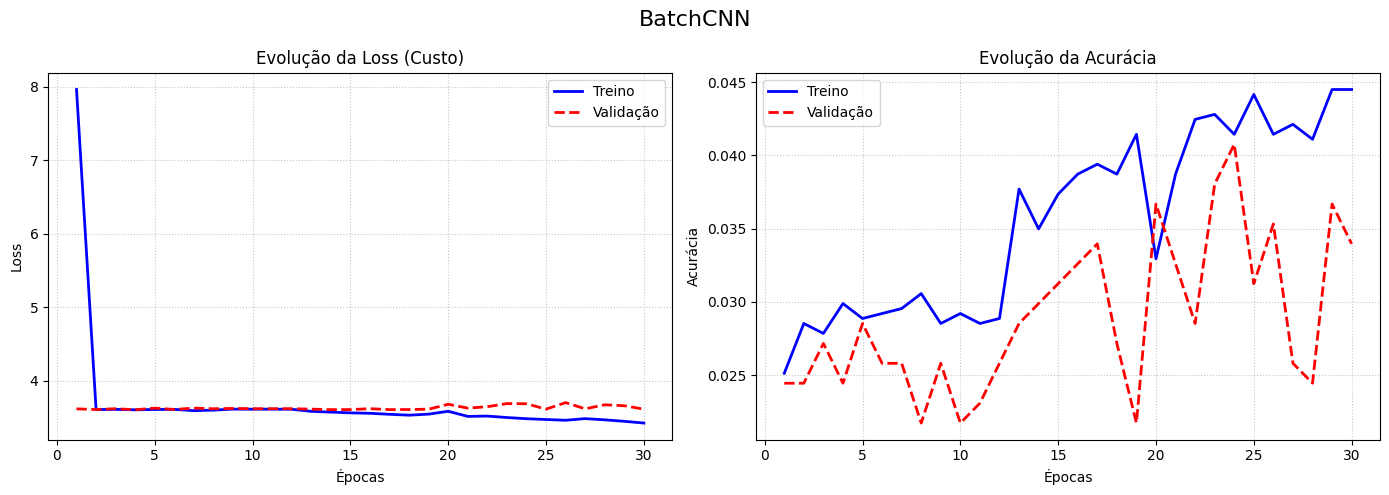

In [60]:
print('##### TREINANDO BATCHCNN #####')
epochs = 30
model_batchcnn = model_batchcnn.to(device)
optmizer = torch.optim.Adam(model_batchcnn.parameters(), learning_rate)
hist_batchcnn = fit(model_batchcnn, train_dataloader, val_dataloader, optmizer, criterion, device, epochs)
plot_history(hist_batchcnn, title="BatchCNN")

##### TREINANDO SIMPLECNN COM DATA AUGMENTATION #####
Epoch 1
-------------------------------
t_loss: 3.665745786998583| t_acc: 0.027853260869565216| v_loss: 3.6013986666997275| v_acc: 0.029891304347826088
Epoch 2
-------------------------------
t_loss: 3.5160025565520576| t_acc: 0.06351902173913043| v_loss: 3.478729565938314| v_acc: 0.07880434782608696
Epoch 3
-------------------------------
t_loss: 3.2310125827789307| t_acc: 0.1171875| v_loss: 3.2600701252619424| v_acc: 0.12092391304347826
Epoch 4
-------------------------------
t_loss: 2.893306535223256| t_acc: 0.2000679347826087| v_loss: 3.287709434827169| v_acc: 0.13994565217391305
Epoch 5
-------------------------------
t_loss: 2.541224858035212| t_acc: 0.29313858695652173| v_loss: 3.3536366621653237| v_acc: 0.13994565217391305
Epoch 6
-------------------------------
t_loss: 2.1128991453543953| t_acc: 0.40625| v_loss: 3.629643718401591| v_acc: 0.12771739130434784
Epoch 7
-------------------------------
t_loss: 1.6113804630611255|

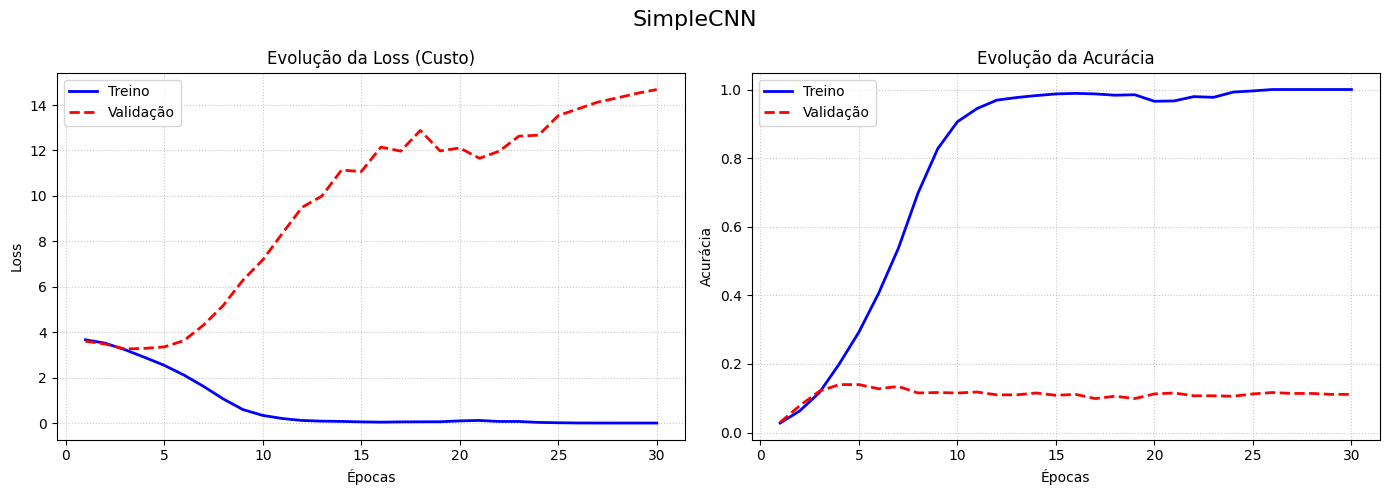

In [61]:
print('##### TREINANDO SIMPLECNN COM DATA AUGMENTATION #####')
epochs = 30
# aplicando data augmentation
val_dataset.dataset = copy.copy(val_dataset.dataset)
train_dataset.dataset.transform = train_transforms

model_simplecnn = SimpleCNN().to(device)
optmizer = torch.optim.Adam(model_simplecnn.parameters(), learning_rate)
hist_simplecnn = fit(model_simplecnn, train_dataloader, val_dataloader, optmizer, criterion, device, epochs)
plot_history(hist_simplecnn, title="SimpleCNN")


##### TREINANDO COMPLETECNN #####
Epoch 1
-------------------------------
t_loss: 3.9792953729629517| t_acc: 0.028532608695652172| v_loss: 3.717245578765869| v_acc: 0.036684782608695655
Epoch 2
-------------------------------
t_loss: 3.5996749245602153| t_acc: 0.036345108695652176| v_loss: 3.583155612150828| v_acc: 0.042119565217391304
Epoch 3
-------------------------------
t_loss: 3.576888037764508| t_acc: 0.04517663043478261| v_loss: 3.55329696337382| v_acc: 0.04755434782608696
Epoch 4
-------------------------------
t_loss: 3.5286693365677544| t_acc: 0.049592391304347824| v_loss: 3.520641565322876| v_acc: 0.028532608695652172
Epoch 5
-------------------------------
t_loss: 3.4925909923470537| t_acc: 0.05400815217391304| v_loss: 3.4607510566711426| v_acc: 0.04483695652173913
Epoch 6
-------------------------------
t_loss: 3.4567403948825337| t_acc: 0.058084239130434784| v_loss: 3.4830184976259866| v_acc: 0.058423913043478264
Epoch 7
-------------------------------
t_loss: 3.42092183

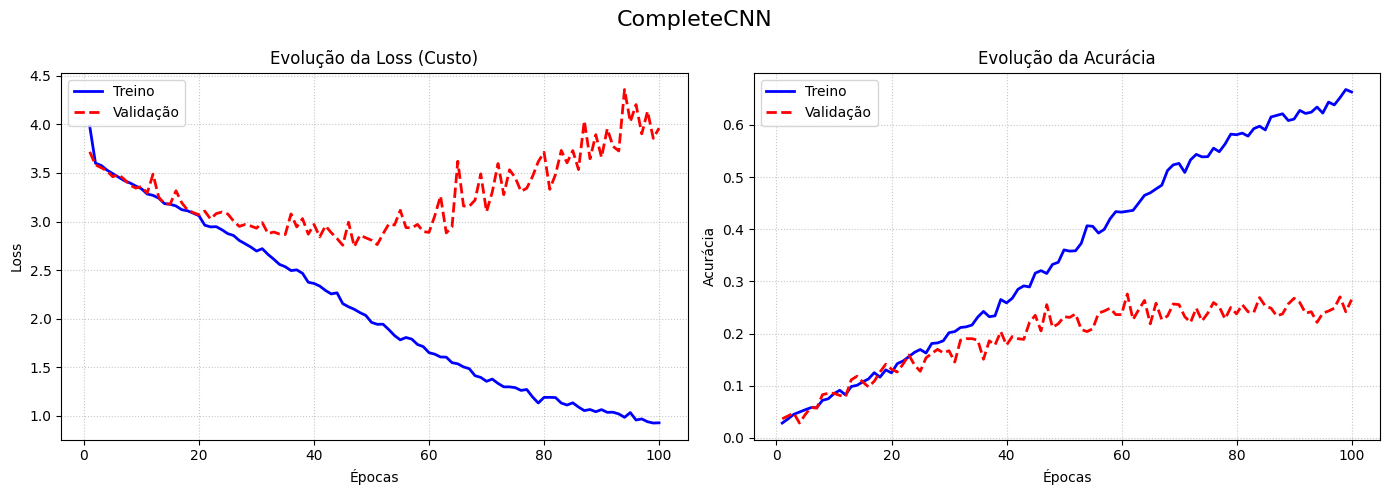

In [62]:
print('##### TREINANDO COMPLETECNN #####') # aplicando dropout
model_completecnn = CompleteCNN().to(device)
epochs = 100
optmizer = torch.optim.Adam(model_completecnn.parameters(), lr=learning_rate)
hist_completecnn = fit(model_completecnn, train_dataloader, val_dataloader, optmizer, criterion, device, epochs)

plot_history(hist_completecnn, title="CompleteCNN")

In [63]:
#complete 2

class CompleteGAPCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.bnorm0 = nn.BatchNorm2d(3)
        
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.bnorm1 = nn.BatchNorm2d(16)
        self.relu1 = nn.ReLU()
        self.conv12 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.bnorm12 = nn.BatchNorm2d(32) 
        self.relu12 = nn.ReLU()
        self.pool12 = nn.MaxPool2d(kernel_size=2)

        self.conv2 = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.bnorm2 = nn.BatchNorm2d(32)
        self.relu2 = nn.ReLU()
        self.conv22 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bnorm22 = nn.BatchNorm2d(64)
        self.relu22 = nn.ReLU()
        self.pool22 = nn.MaxPool2d(kernel_size=2)

        self.conv3 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bnorm3 = nn.BatchNorm2d(64)
        self.relu3 = nn.ReLU()
        self.conv32 = nn.Conv2d(64, 96, kernel_size=3, padding=1)
        self.bnorm32 = nn.BatchNorm2d(96)
        self.relu32 = nn.ReLU()
        self.pool32 = nn.MaxPool2d(kernel_size=2)

    
        self.conv4 = nn.Conv2d(96, 96, kernel_size=3, padding=1)
        self.bnorm4 = nn.BatchNorm2d(96)
        self.relu4 = nn.ReLU()
        self.conv42 = nn.Conv2d(96, 128, kernel_size=3, padding=1)
        self.bnorm42 = nn.BatchNorm2d(128)
        self.relu42 = nn.ReLU()
        self.pool42 = nn.MaxPool2d(kernel_size=2)

        self.conv5 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.bnorm5 = nn.BatchNorm2d(128)
        self.relu5 = nn.ReLU()
        self.conv52 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.bnorm52 = nn.BatchNorm2d(128)
        self.relu52 = nn.ReLU()
        self.pool52 = nn.MaxPool2d(kernel_size=2)

        self.global_pool = nn.AdaptiveAvgPool2d((1,1))
        self.flatten = nn.Flatten()


        self.dropout = nn.Dropout(p = 0.5)

        self.fc2 = nn.Linear(128, 37) 
        
    def forward(self, x):
        x = self.bnorm0(x)
        x = self.relu1(self.bnorm1(self.conv1(x)))
        x = self.pool12(self.relu12(self.bnorm12(self.conv12(x))))

        x = self.relu2(self.bnorm2(self.conv2(x)))
        x = self.pool22(self.relu22(self.bnorm22(self.conv22(x))))

        x = self.relu3(self.bnorm3(self.conv3(x)))
        x = self.pool32(self.relu32(self.bnorm32(self.conv32(x))))

        x = self.relu4(self.bnorm4(self.conv4(x)))
        x = self.pool42(self.relu42(self.bnorm42(self.conv42(x))))

        x = self.relu5(self.bnorm5(self.conv5(x)))
        x = self.pool52(self.relu52(self.bnorm52(self.conv52(x))))
        
        x = self.global_pool(x)
        x = self.flatten(x)
        
        x = self.dropout(x)

        logits = self.fc2(x)
        
        return logits

##### TREINANDO COMPLETECNN #####
Epoch 1
-------------------------------
t_loss: 3.677546563355819| t_acc: 0.03328804347826087| v_loss: 3.5854320327440896| v_acc: 0.03940217391304348
Epoch 2
-------------------------------
t_loss: 3.542788318965746| t_acc: 0.03974184782608696| v_loss: 3.552672247091929| v_acc: 0.04483695652173913
Epoch 3
-------------------------------
t_loss: 3.500582192255103| t_acc: 0.05366847826086957| v_loss: 3.4855231841405234| v_acc: 0.05298913043478261
Epoch 4
-------------------------------
t_loss: 3.440602385479471| t_acc: 0.07370923913043478| v_loss: 3.425672789414724| v_acc: 0.07472826086956522
Epoch 5
-------------------------------
t_loss: 3.3814753138500713| t_acc: 0.08627717391304347| v_loss: 3.4270352125167847| v_acc: 0.07744565217391304
Epoch 6
-------------------------------
t_loss: 3.2975039793097456| t_acc: 0.10292119565217392| v_loss: 3.366547167301178| v_acc: 0.08967391304347826
Epoch 7
-------------------------------
t_loss: 3.231444944506106| 

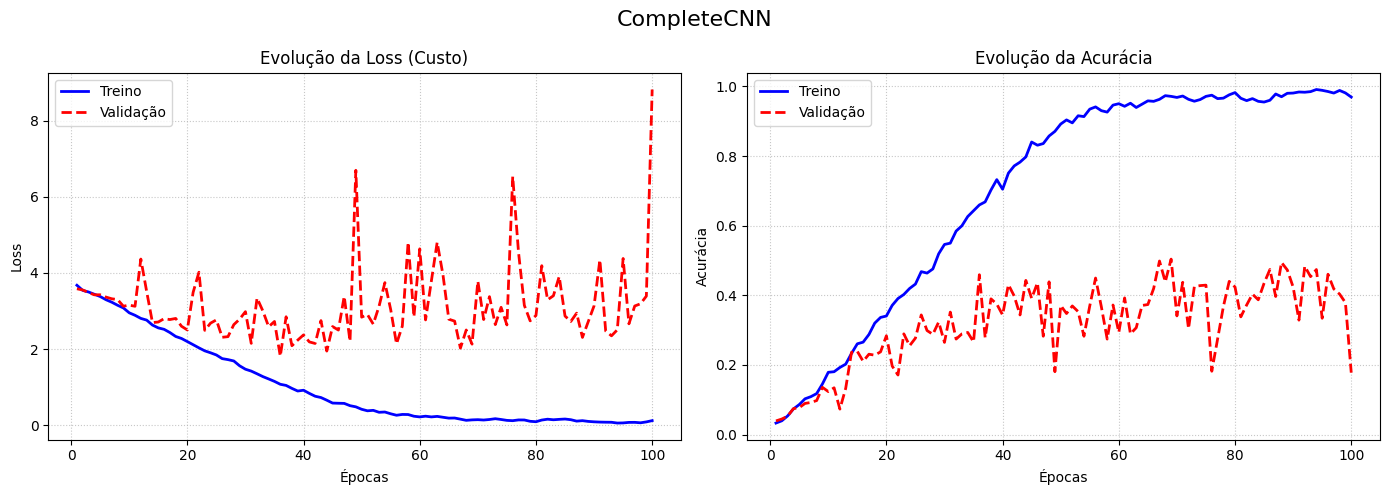

In [64]:
print('##### TREINANDO COMPLETECNN #####') # aplicando weight_decay, dropout e global average pooling
model_completegapcnn = CompleteGAPCNN().to(device)
epochs = 100
optmizer = torch.optim.Adam(model_completegapcnn.parameters(), lr=learning_rate,weight_decay=1e-4)
hist_completegapcnn = fit(model_completegapcnn, train_dataloader, val_dataloader, optmizer, criterion, device, epochs)

plot_history(hist_completegapcnn, title="CompleteCNN")

### Resposta 7.4

Liste as modificações escolhidas e justifique em 1–2 linhas por que você decidiu testá-las.

Modelos testados:

- Deep CNN
- Batch CNN
- Data Augmentation
- Complete CNN
- CompleteGAP CNN

As três primeiras redes tinham como objetivo comparar o impacto de cada modificação na rede inicial, e de após isso juntar todas essas técnicas em uma só, a Complete CNN.

A CompleteGAP CNN é a Complete CNN com Global Average Pooling(GAP) e com weight decay. O GAP e o weight decay foram usados na tentativa de diminuir o overfitting, uma vez que a loss de validação crescia muito a partir da época 40. Note que a partir da década 40 a acurácia de validação permanecia quase constante, sugerindo que o modelo chutava com muita certeza resultados errados.

## 8. Analise e discuta o efeito das mudanças

Com base nos experimentos da parte anterior:

**Tarefas**
1. Discuta quais mudanças ajudaram mais.
2. Discuta quais mudanças pouco ajudaram ou pioraram o resultado.
3. Comente possíveis razões para o comportamento observado.
4. Indique qual modelo/configuração você levará para a etapa final.

Use evidências das métricas e curvas.


### Resposta 8

Escreva sua análise aqui.


## 9. Treine usando uma ResNet pré-treinada

Agora use **transfer learning** com uma **ResNet pré-treinada**.

**Tarefas**
1. Carregue uma ResNet pré-treinada do `torchvision`.
2. Adapte a última camada para o número de classes.
3. Treine ao menos uma versão usando transfer learning.
4. Compare com sua melhor CNN da Parte 7.

**Sugestão.**
Você pode começar congelando a maior parte da rede e depois testar fine-tuning.


In [65]:
# TODO:
# - carregar uma ResNet pré-treinada
# - adaptar a camada final
# - treinar
# - avaliar e comparar

# Dica:
# from torchvision.models import resnet18, ResNet18_Weights

# Escreva seu código aqui




### Resposta 9.4

Compare a ResNet com sua melhor CNN anterior. O ganho compensou?


## 10. Avaliações finais

Escolha seu melhor modelo final e faça uma avaliação mais detalhada.

**Tarefas**
1. Avalie no conjunto de teste.
2. Reporte:
   - loss;
   - acurácia;
   - matriz de confusão.
3. Mostre algumas imagens classificadas incorretamente.
4. Identifique pares de classes que geram mais confusão.
5. Discuta brevemente os principais erros do modelo.

**Observação.**
Use esta parte para mostrar que você inspecionou o comportamento do modelo além da acurácia final.


In [66]:
# TODO:
# - avaliar no teste
# - calcular matriz de confusão
# - mostrar erros
# - discutir pares confusos

# Sugestão:
# use sklearn.metrics.confusion_matrix ou implementação própria

# Escreva seu código aqui


### Resposta 10.5

Discuta os erros mais importantes observados na avaliação final.


## 11. Bônus — Robustez

Faça um teste simples de robustez com o seu melhor modelo.

**Exemplos de variações possíveis**
- reduzir a resolução da imagem;
- adicionar ruído leve;
- mudar brilho/contraste;
- aplicar blur leve;
- testar imagens com crop diferente.

**Tarefas**
1. Escolha uma perturbação simples.
2. Compare o desempenho antes e depois.
3. Mostre alguns exemplos.
4. Comente o que isso sugere sobre a robustez do modelo.


In [67]:
# TODO:
# - definir uma perturbação simples
# - reavaliar o melhor modelo
# - comparar métricas
# - mostrar exemplos

# Escreva seu código aqui

## Critérios de avaliação

A correção levará em conta:
- **implementação correta** dos componentes pedidos;
- **qualidade experimental** das comparações;
- **clareza da análise** dos resultados;
- **organização** do notebook;
- **coerência** entre conclusões e evidências.
